# Tutorial: U-Net para segmentación pulmonar

Este notebook explica **U-Net** paso a paso: qué problema resuelve, cómo está construida, cómo se entrena y qué cuidar. Todo se implementa desde cero en PyTorch y se entrena con el dataset Montgomery + Shenzhen que ya está preparado en el proyecto.

**Contenido**
1. ¿Qué es segmentar?
2. Los datos
3. Arquitectura de U-Net, pieza por pieza
4. Preparar los datos para entrenar (Dataset, aumentos, DataLoader)
5. Función de pérdida y métricas
6. Entrenamiento
7. Evaluación en el conjunto de prueba
8. Aplicación a TBX11K
9. Qué hay que tener en cuenta
10. Attention U-Net: la variante que viene después
11. Relación con el proyecto

**Requisitos**
- Entorno instalado (`pip install -r requirements.txt` y `pip install -e .`).
- Dataset preparado: `python -m tbseg.segmentation.prepare`.
- GPU recomendada. En CPU funciona, pero el entrenamiento tarda mucho más; en ese caso reduce `EPOCHS`.

> **Simplificación:** para que el tutorial corra en pocos minutos se trabaja a **256×256**. El proyecto usará 512×512; la técnica es exactamente la misma.

### 0. Configuración

In [1]:
import copy
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.patches import FancyArrowPatch, Rectangle
from torch.utils.data import DataLoader, Dataset

from tbseg.config import SEED, SEGTRAIN_CSV, SEGTRAIN_DIR
from tbseg.data import load_gray, load_subset

IMG_SIZE = 256   # resolución de trabajo del tutorial
BATCH_SIZE = 16
EPOCHS = 30
LR = 1e-3

# Reproducibilidad: misma semilla para numpy y PyTorch
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DEVICE, f"({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else "")

# Colores: azul = máscara real, naranja = predicción
C_TRUE, C_PRED = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

Dispositivo: cuda (NVIDIA GeForce RTX 3050 6GB Laptop GPU)


## 1. ¿Qué es segmentar?

Hay tres tareas clásicas de visión por computador, de menor a mayor detalle:

| Tarea | Pregunta | Salida |
|---|---|---|
| Clasificación | ¿Qué hay en la imagen? | Una etiqueta por imagen ("TB") |
| Detección | ¿Dónde está, aproximadamente? | Cajas (como las anotaciones de TBX11K) |
| **Segmentación** | ¿Qué píxeles pertenecen a cada cosa? | **Una etiqueta por píxel** |

Segmentar es clasificar **cada píxel**. En segmentación pulmonar cada píxel es "pulmón" (1) o "no pulmón" (0). El resultado es la **máscara**: una imagen del mismo tamaño que la radiografía con 0 y 1.

Entrenar un segmentador es aprendizaje **supervisado**: la red recibe pares *(radiografía, máscara correcta)* y aprende a producir la máscara a partir de la radiografía. Una vez entrenada, recibe solo radiografías.

## 2. Los datos

TBX11K no trae máscaras de pulmón, así que la red se entrena con un dataset externo que sí las tiene: la unión de dos colecciones públicas de la National Library of Medicine de EE. UU. (Jaeger et al., 2014).

| | Montgomery | Shenzhen | Total |
|---|---|---|---|
| Origen | Programa de control de TB del condado de Montgomery (Maryland, EE. UU.) | Hospital n.º 3 de Shenzhen (China) | |
| Radiografías con máscara | **138** (20 %) | **566** (80 %) | **704** |
| Normales / TB | 80 / 58 | 279 / 287 | 359 / 345 |
| Tamaño original | 4020×4892 o 4892×4020 | ≈3000×2950 | |
| Máscaras | Manuales, incluidas en el dataset | Manuales, de Stirenko et al. (2018) | |

Shenzhen publica 662 radiografías, pero solo 566 tienen máscara; esas son las que se usan. `python -m tbseg.segmentation.prepare` lleva todas las imágenes y máscaras a 512×512 (sin conservar la proporción, igual que en TBX11K).

**Desbalance entre orígenes.** El diagnóstico está equilibrado (≈50 % normal, 50 % TB), pero el origen no: **4 de cada 5 imágenes vienen de Shenzhen**. En consecuencia:
- La red ve sobre todo radiografías de un hospital, con su equipo, su población y su criterio de anotación. El riesgo es que se ajuste a ese estilo y rinda peor en Montgomery (o en cualquier hospital distinto).
- El Dice global del test (106 imágenes) queda dominado por las 85 de Shenzhen. Montgomery aporta solo 21, así que su estimación es más inestable.

Para que el desbalance no se esconda:
- La división se **estratifica por origen y diagnóstico**, así que train, val y test mantienen las mismas proporciones (tabla de abajo).
- En la sección 7 el Dice se reporta **por origen**, no solo el promedio.

`segtrain_split.csv` lista las 704 radiografías y las divide en:
- **train** (70 %): con lo que la red aprende.
- **val** (15 %): para vigilar el entrenamiento y elegir el mejor modelo.
- **test** (15 %): se usa **una sola vez**, al final, para reportar el desempeño.

split,test,train,val,total
source,,,,
montgomery,21,96,21,138
shenzhen,85,396,85,566
total,106,492,106,704


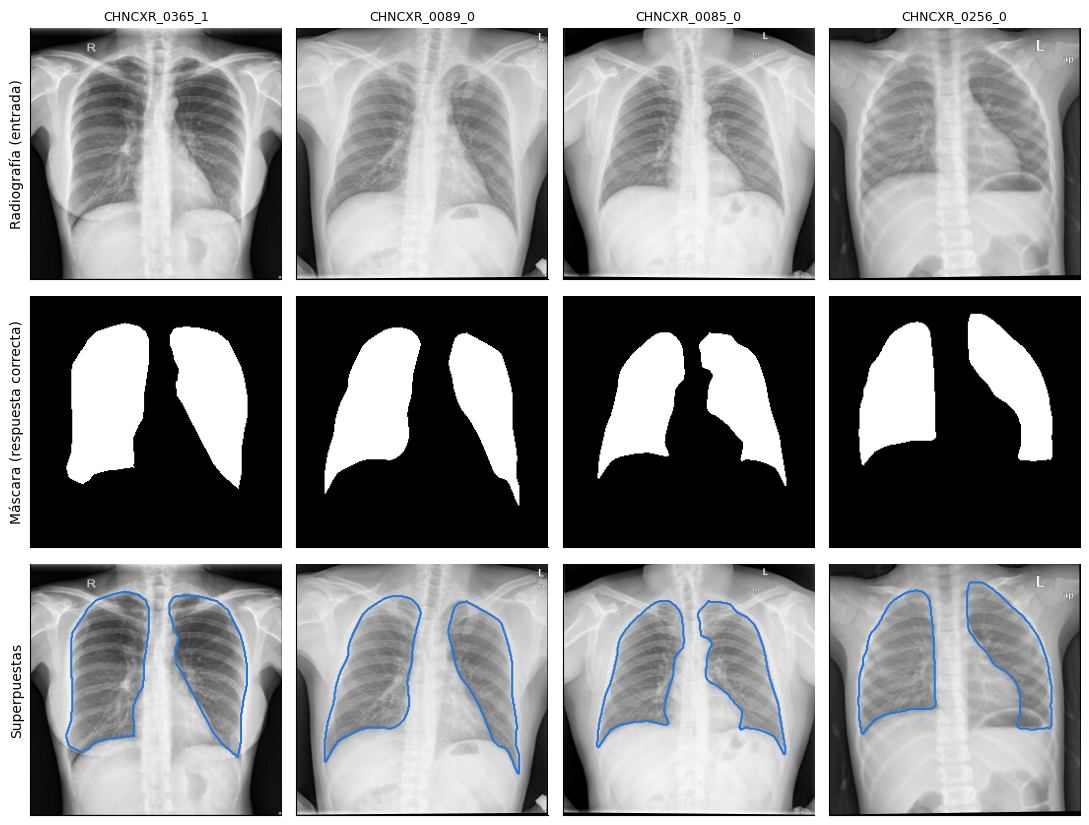

In [2]:
split = pd.read_csv(SEGTRAIN_CSV)
display(pd.crosstab(split["source"], split["split"], margins=True, margins_name="total"))

def load_pair(image_id, size=IMG_SIZE):
    """Imagen (float32 en [0, 1]) y máscara (float32 en {0, 1}) a size x size."""
    img = cv2.imread(str(SEGTRAIN_DIR / "images" / f"{image_id}.png"), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(SEGTRAIN_DIR / "masks" / f"{image_id}.png"), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_AREA)
    return (img / 255.0).astype(np.float32), (mask >= 128).astype(np.float32)

ids = split["image_id"].sample(4, random_state=SEED).tolist()
fig, axes = plt.subplots(3, 4, figsize=(11, 8.4))
for c, image_id in enumerate(ids):
    img, mask = load_pair(image_id)
    axes[0, c].imshow(img, cmap="gray"); axes[0, c].set_title(image_id, fontsize=9)
    axes[1, c].imshow(mask, cmap="gray")
    axes[2, c].imshow(img, cmap="gray"); axes[2, c].contour(mask, levels=[0.5], colors=C_TRUE, linewidths=1.5)
for r, name in enumerate(["Radiografía (entrada)", "Máscara (respuesta correcta)", "Superpuestas"]):
    axes[r, 0].set_ylabel(name, fontsize=10)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

Un dato importante: el pulmón ocupa solo cerca del **25 %** de los píxeles. Esto importa al elegir la función de pérdida (sección 5).

## 3. Arquitectura de U-Net

U-Net fue propuesta por Ronneberger, Fischer y Brox (2015) para segmentar imágenes biomédicas con **pocos datos de entrenamiento**.

### 3.1 La idea: *qué* y *dónde*

Para segmentar bien, la red necesita dos cosas:
- **Contexto (el "qué")**: para saber que una zona oscura es pulmón y no fondo, hay que ver una región amplia de la imagen.
- **Precisión espacial (el "dónde")**: el borde del pulmón debe quedar en el píxel correcto.

Las redes convolucionales ganan contexto **reduciendo** la imagen paso a paso, pero así pierden detalle espacial. U-Net resuelve el conflicto con tres partes:

1. **Codificador (contracción, lado izquierdo de la "U")**: reduce la resolución a la mitad en cada nivel y duplica el número de canales. Aprende *qué* hay.
2. **Decodificador (expansión, lado derecho)**: recupera la resolución paso a paso hasta el tamaño original.
3. **Conexiones de salto (*skip connections*)**: en cada nivel copian los mapas del codificador al decodificador. Le devuelven al decodificador el detalle espacial que se perdió al reducir. **Son la clave de U-Net.**

El nombre viene de la forma del diagrama:

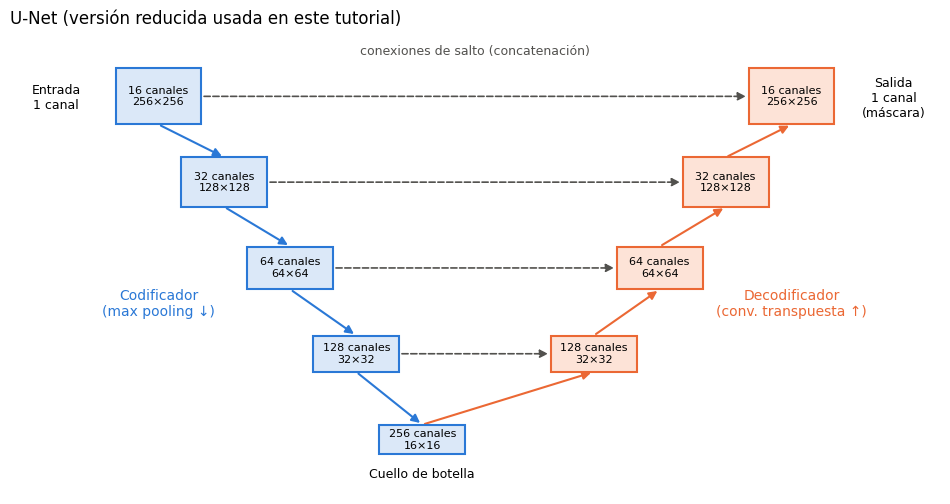

In [3]:
def draw_unet(channels=(16, 32, 64, 128, 256), size=IMG_SIZE):
    fig, ax = plt.subplots(figsize=(12, 6))
    n = len(channels)
    box_w, gap_y = 1.3, 1.25
    enc_x = [i * 1.0 for i in range(n)]
    dec_x = [2 * (n - 1) - i * 1.0 + 1.6 for i in range(n)]
    for lvl, ch in enumerate(channels):
        y = -lvl * gap_y
        h = 0.85 - lvl * 0.1
        ax.add_patch(Rectangle((enc_x[lvl], y), box_w, h, fc="#dbe8f8", ec="#2a78d6", lw=1.5))
        ax.text(enc_x[lvl] + box_w / 2, y + h / 2, f"{ch} canales\n{size // 2**lvl}×{size // 2**lvl}", ha="center", va="center", fontsize=8)
        if lvl < n - 1:
            ax.add_patch(Rectangle((dec_x[lvl], y), box_w, h, fc="#fde3d7", ec="#eb6834", lw=1.5))
            ax.text(dec_x[lvl] + box_w / 2, y + h / 2, f"{ch} canales\n{size // 2**lvl}×{size // 2**lvl}", ha="center", va="center", fontsize=8)
            # conexión de salto
            ax.add_patch(FancyArrowPatch((enc_x[lvl] + box_w, y + h / 2), (dec_x[lvl], y + h / 2),
                                         arrowstyle="-|>", mutation_scale=12, color="#52514e", ls="--", lw=1.2))
            # bajar (max pooling)
            ax.add_patch(FancyArrowPatch((enc_x[lvl] + box_w / 2, y), (enc_x[lvl + 1] + box_w / 2, y - gap_y + 0.85 - (lvl + 1) * 0.1),
                                         arrowstyle="-|>", mutation_scale=12, color="#2a78d6", lw=1.5))
            # subir (convolución transpuesta)
            up_from = dec_x[lvl + 1] if lvl + 1 < n - 1 else enc_x[n - 1]
            ax.add_patch(FancyArrowPatch((up_from + box_w / 2, y - gap_y + 0.85 - (lvl + 1) * 0.1), (dec_x[lvl] + box_w / 2, y),
                                         arrowstyle="-|>", mutation_scale=12, color="#eb6834", lw=1.5))
    ax.text(enc_x[0] - 0.9, 0.4, "Entrada\n1 canal", ha="center", va="center", fontsize=9)
    ax.text(dec_x[0] + box_w + 0.9, 0.4, "Salida\n1 canal\n(máscara)", ha="center", va="center", fontsize=9)
    ax.text(enc_x[1] - 0.35, -2.9, "Codificador\n(max pooling ↓)", color="#2a78d6", fontsize=10, ha="center")
    ax.text(dec_x[1] + box_w + 0.35, -2.9, "Decodificador\n(conv. transpuesta ↑)", color="#eb6834", fontsize=10, ha="center")
    ax.text((enc_x[0] + dec_x[0] + box_w) / 2, 1.05, "conexiones de salto (concatenación)", ha="center", fontsize=9, color="#52514e")
    ax.text(enc_x[n - 1] + box_w / 2, -(n - 1) * gap_y - 0.35, "Cuello de botella", ha="center", fontsize=9)
    ax.set_xlim(-1.6, dec_x[0] + box_w + 1.6); ax.set_ylim(-(n - 1) * gap_y - 0.6, 1.4)
    ax.axis("off")
    ax.set_title("U-Net (versión reducida usada en este tutorial)", loc="left")
    plt.show()

draw_unet()

### 3.2 Bloque básico: doble convolución

Cada caja del diagrama es un **bloque de dos convoluciones 3×3**, cada una seguida de normalización y activación:

`Conv 3×3 → BatchNorm → ReLU → Conv 3×3 → BatchNorm → ReLU`

- **Convolución 3×3**: un filtro de 3×3 píxeles recorre la imagen y responde a patrones locales (bordes, texturas). Cada filtro produce un "mapa de características" (un canal). Con `padding=1` la salida conserva el tamaño.
- **BatchNorm**: normaliza las activaciones de cada canal dentro del lote. Estabiliza y acelera el entrenamiento. *La U-Net original no la usaba; hoy es estándar.*
- **ReLU**: activación no lineal (`max(0, x)`). Sin ella, apilar capas equivaldría a una sola capa lineal.

In [4]:
class DoubleConv(nn.Module):
    """Conv3x3 -> BN -> ReLU, dos veces. Conserva el tamaño espacial."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

x = torch.randn(1, 1, IMG_SIZE, IMG_SIZE)   # (lote, canales, alto, ancho)
print("Entrada:", tuple(x.shape), "-> DoubleConv(1, 16):", tuple(DoubleConv(1, 16)(x).shape))

Entrada: (1, 1, 256, 256) -> DoubleConv(1, 16): (1, 16, 256, 256)


### 3.3 Bajar y subir de resolución

- **Bajar (codificador): *max pooling* 2×2.** Toma el máximo de cada ventana de 2×2 y reduce el alto y el ancho a la mitad. Cada píxel del mapa reducido "ve" una región más grande de la imagen original: así se gana contexto.
- **Subir (decodificador): convolución transpuesta 2×2 con paso 2.** Es la operación inversa aprendible: duplica el alto y el ancho.

In [5]:
x = torch.randn(1, 32, 64, 64)
print("Max pooling:           ", tuple(x.shape), "->", tuple(nn.MaxPool2d(2)(x).shape))
print("Convolución transpuesta:", tuple(x.shape), "->", tuple(nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)(x).shape))

Max pooling:            (1, 32, 64, 64) -> (1, 32, 32, 32)
Convolución transpuesta: (1, 32, 64, 64) -> (1, 16, 128, 128)


### 3.4 Conexiones de salto

En cada nivel del decodificador:
1. Se sube la resolución del mapa que viene de abajo.
2. Se **concatena** (se apilan los canales) con el mapa del codificador del mismo nivel.
3. Un `DoubleConv` combina ambas fuentes: el contexto que viene de abajo y el detalle que viene del salto.

Por eso el decodificador recibe el doble de canales en la entrada de cada bloque.

### 3.5 La red completa

In [6]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, channels=(16, 32, 64, 128, 256)):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        # Codificador: un DoubleConv por nivel
        self.encoder = nn.ModuleList()
        prev = in_channels
        for ch in channels:
            self.encoder.append(DoubleConv(prev, ch))
            prev = ch
        # Decodificador: subir resolución + DoubleConv (que recibe el doble de canales por la concatenación)
        self.up = nn.ModuleList()
        self.decoder = nn.ModuleList()
        for ch in reversed(channels[:-1]):
            self.up.append(nn.ConvTranspose2d(ch * 2, ch, kernel_size=2, stride=2))
            self.decoder.append(DoubleConv(ch * 2, ch))
        # Capa final: convolución 1x1 que reduce a 1 canal (un valor por píxel)
        self.head = nn.Conv2d(channels[0], out_channels, kernel_size=1)

    def forward(self, x, verbose=False):
        skips = []
        for i, enc in enumerate(self.encoder):
            if i > 0:
                x = self.pool(x)
            x = enc(x)
            skips.append(x)
            if verbose:
                print(f"  codificador nivel {i}: {tuple(x.shape)}")
        skips.pop()  # el último nivel es el cuello de botella, no tiene salto
        for up, dec in zip(self.up, self.decoder):
            x = up(x)
            skip = skips.pop()
            x = dec(torch.cat([skip, x], dim=1))  # conexión de salto
            if verbose:
                print(f"  decodificador:        {tuple(x.shape)}")
        return self.head(x)  # logits: valores reales sin acotar


model = UNet()
print("Recorrido de un tensor por la red:")
out = model(torch.randn(1, 1, IMG_SIZE, IMG_SIZE), verbose=True)
print("Salida:", tuple(out.shape))
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters()):,}")

Recorrido de un tensor por la red:
  codificador nivel 0: (1, 16, 256, 256)
  codificador nivel 1: (1, 32, 128, 128)
  codificador nivel 2: (1, 64, 64, 64)
  codificador nivel 3: (1, 128, 32, 32)
  codificador nivel 4: (1, 256, 16, 16)
  decodificador:        (1, 128, 32, 32)
  decodificador:        (1, 64, 64, 64)
  decodificador:        (1, 32, 128, 128)
  decodificador:        (1, 16, 256, 256)
Salida: (1, 1, 256, 256)
Parámetros entrenables: 1,942,289


Se observa la forma de "U": la resolución baja de 256 a 16 mientras los canales suben de 16 a 256, y luego se recorre el camino inverso. **La salida tiene el mismo tamaño que la entrada**: un valor por píxel.

**Logits y sigmoide.** La red devuelve *logits*, números reales sin límite. La función sigmoide los convierte en probabilidades entre 0 y 1: `p = 1 / (1 + e^(-logit))`. Para obtener la máscara se aplica un umbral: pulmón si `p > 0.5`.

**Diferencias con la U-Net original (2015):**

| | Original | Este tutorial |
|---|---|---|
| Canales | 64 → 1024 | 16 → 256 (≈ 1,9 M de parámetros frente a ≈ 31 M) |
| Convoluciones | Sin *padding* (la salida es más pequeña y hay que recortar) | Con *padding* (misma forma de entrada y salida) |
| Normalización | No | BatchNorm |

Con ~500 imágenes de entrenamiento y una tarea relativamente simple (el pulmón es una estructura grande y bien definida), una red más pequeña basta y se sobreajusta menos.

## 4. Preparar los datos para entrenar

### 4.1 Aumento de datos (*data augmentation*)

Con pocas imágenes, la red puede **memorizar** el conjunto de entrenamiento en lugar de aprender a generalizar. El aumento de datos genera variaciones realistas de cada imagen en cada época, así la red casi nunca ve dos veces exactamente la misma imagen.

Reglas importantes:
- **Las transformaciones geométricas se aplican igual a la imagen y a su máscara.** Si se rota la radiografía y no la máscara, la respuesta correcta queda desalineada.
- **Las transformaciones de intensidad (brillo, contraste) se aplican solo a la imagen.** La máscara no cambia.
- **Deben ser realistas.** Rotaciones pequeñas (±10°) y cambios de exposición ocurren en la práctica. Por eso **no se usa volteo horizontal**: produciría radiografías con el corazón a la derecha, que no existen en los datos reales.
- **Solo en entrenamiento.** Validación y prueba usan las imágenes tal cual.

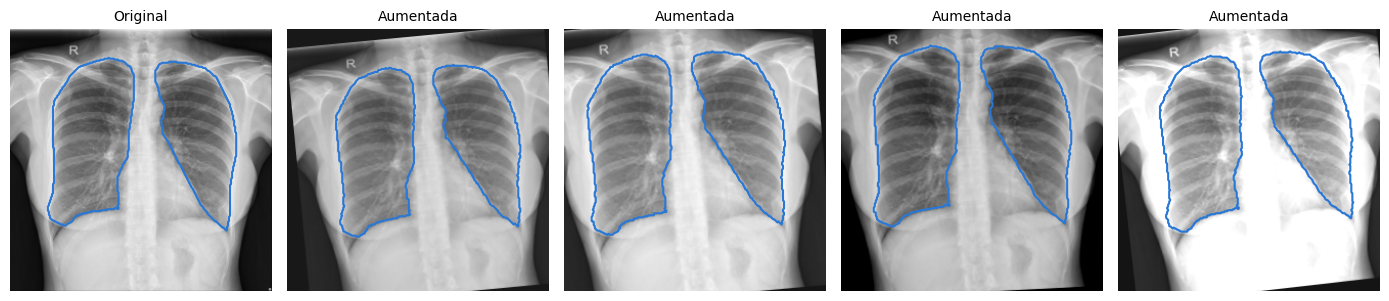

In [7]:
rng = np.random.default_rng(SEED)

def augment(img, mask):
    """Rotación, escala y traslación pequeñas (imagen y máscara) + brillo/contraste (solo imagen)."""
    size = img.shape[0]
    angle = rng.uniform(-10, 10)
    scale = rng.uniform(0.9, 1.1)
    shift = rng.uniform(-0.05, 0.05, size=2) * size
    M = cv2.getRotationMatrix2D((size / 2, size / 2), angle, scale)
    M[:, 2] += shift
    img = cv2.warpAffine(img, M, (size, size), flags=cv2.INTER_LINEAR, borderValue=0)
    mask = cv2.warpAffine(mask, M, (size, size), flags=cv2.INTER_NEAREST, borderValue=0)  # NEAREST: sigue siendo 0/1
    contrast, brightness = rng.uniform(0.8, 1.2), rng.uniform(-0.1, 0.1)
    img = np.clip(img * contrast + brightness, 0, 1)
    return img, mask

img, mask = load_pair(ids[0])
fig, axes = plt.subplots(1, 5, figsize=(14, 3.2))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=1); axes[0].contour(mask, levels=[0.5], colors=C_TRUE)
axes[0].set_title("Original", fontsize=10)
for ax in axes[1:]:
    a_img, a_mask = augment(img, mask)
    ax.imshow(a_img, cmap="gray", vmin=0, vmax=1); ax.contour(a_mask, levels=[0.5], colors=C_TRUE)
    ax.set_title("Aumentada", fontsize=10)
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

### 4.2 `Dataset` y `DataLoader`

PyTorch organiza los datos con dos piezas:
- **`Dataset`**: sabe cuántos ejemplos hay (`__len__`) y cómo entregar el ejemplo *i* (`__getitem__`).
- **`DataLoader`**: agrupa ejemplos en **lotes** (*batches*) y los baraja en cada época.

Como el dataset es pequeño (~180 MB a 256×256), se carga completo en memoria una sola vez para que el entrenamiento sea rápido.

In [8]:
class LungDataset(Dataset):
    def __init__(self, image_ids, train=False):
        pairs = [load_pair(i) for i in image_ids]
        self.images = [p[0] for p in pairs]
        self.masks = [p[1] for p in pairs]
        self.image_ids = list(image_ids)
        self.train = train

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img, mask = self.images[i], self.masks[i]
        if self.train:
            img, mask = augment(img, mask)
        # PyTorch espera (canales, alto, ancho)
        return torch.from_numpy(img)[None], torch.from_numpy(mask)[None]


datasets = {s: LungDataset(split.loc[split["split"] == s, "image_id"], train=(s == "train"))
            for s in ["train", "val", "test"]}
loaders = {
    "train": DataLoader(datasets["train"], batch_size=BATCH_SIZE, shuffle=True),
    "val": DataLoader(datasets["val"], batch_size=BATCH_SIZE),
    "test": DataLoader(datasets["test"], batch_size=BATCH_SIZE),
}
images, masks = next(iter(loaders["train"]))
print({s: len(d) for s, d in datasets.items()})
print("Un lote de entrenamiento: imágenes", tuple(images.shape), "| máscaras", tuple(masks.shape))

{'train': 492, 'val': 106, 'test': 106}
Un lote de entrenamiento: imágenes (16, 1, 256, 256) | máscaras (16, 1, 256, 256)


## 5. Función de pérdida y métricas

La **función de pérdida** mide qué tan lejos está la predicción de la máscara correcta. Entrenar es ajustar los pesos para que baje.

### 5.1 Entropía cruzada binaria (BCE)

Trata cada píxel como una clasificación binaria independiente y penaliza las probabilidades lejanas a la respuesta correcta:

$$\text{BCE} = -\frac{1}{N}\sum_{i}\big[y_i \log p_i + (1-y_i)\log(1-p_i)\big]$$

Da una señal de aprendizaje estable en cada píxel. **Su problema** es que todos los píxeles pesan igual: si el 75 % es fondo, una red que prediga "todo fondo" ya obtiene una pérdida baja y un 75 % de acierto.

### 5.2 Dice

Mide la **superposición** entre la predicción $P$ y la máscara real $Y$:

$$\text{Dice} = \frac{2\,|P \cap Y|}{|P| + |Y|}$$

Vale 1 si coinciden exactamente y 0 si no se tocan. Solo mira la región de interés, así que **no le afecta el desbalance** entre pulmón y fondo. Como pérdida se usa $1 - \text{Dice}$, calculado con probabilidades en lugar de 0/1 para que sea derivable ("Dice suave").

### 5.3 Combinación

Es habitual sumar ambas: **BCE aporta estabilidad píxel a píxel y Dice optimiza directamente la superposición**, que es lo que se quiere.

Ejemplo con una red que predice "todo fondo":

In [9]:
def dice_loss(logits, target, eps=1.0):
    """1 - Dice suave, calculado por imagen y promediado en el lote."""
    probs = torch.sigmoid(logits)
    inter = (probs * target).sum(dim=(1, 2, 3))
    total = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return 1 - ((2 * inter + eps) / (total + eps)).mean()

bce = nn.BCEWithLogitsLoss()  # sigmoide + BCE en una sola operación, numéricamente estable

def loss_fn(logits, target):
    return bce(logits, target) + dice_loss(logits, target)

@torch.no_grad()
def dice_score(logits, target, threshold=0.5):
    """Dice binario (tras el umbral) por imagen. Es la métrica que se reporta."""
    pred = (torch.sigmoid(logits) > threshold).float()
    inter = (pred * target).sum(dim=(1, 2, 3))
    total = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return (2 * inter / total.clamp(min=1)).cpu()

_, target = datasets["val"][0]
target = target[None]
all_background = torch.full_like(target, -10.0)   # logits muy negativos -> probabilidad ~0 en todos los píxeles
accuracy = ((torch.sigmoid(all_background) > 0.5).float() == target).float().mean()
print(f"Predecir 'todo fondo': exactitud por píxel = {accuracy:.1%} | Dice = {dice_score(all_background, target).item():.2f}")

Predecir 'todo fondo': exactitud por píxel = 78.1% | Dice = 0.00


La exactitud por píxel parece aceptable aunque la predicción es inútil; el Dice revela que la superposición es nula. Por eso **se reporta Dice** (y a veces IoU, $|P\cap Y| / |P\cup Y|$, que es una medida equivalente más estricta).

## 6. Entrenamiento

Cada **época** recorre todo el conjunto de entrenamiento una vez. Para cada lote:

1. **Paso hacia adelante**: la red predice los logits.
2. **Pérdida**: se compara la predicción con la máscara real.
3. **Retropropagación** (`loss.backward()`): se calcula cuánto contribuyó cada peso al error (el gradiente).
4. **Optimizador** (`optimizer.step()`): ajusta los pesos en la dirección que reduce la pérdida. Se usa **Adam**, con tasa de aprendizaje `LR` (el tamaño del paso).

Al final de cada época se evalúa en **validación**, sin aumentos y sin actualizar pesos, y se guarda el modelo con **mejor Dice en validación**. Así, si la red empieza a sobreajustarse en las últimas épocas, se conserva la mejor versión.

Dos detalles de PyTorch:
- `model.train()` / `model.eval()`: cambian el comportamiento de BatchNorm. En evaluación usa estadísticas fijas aprendidas; **olvidar `model.eval()` al predecir es un error común**.
- `torch.no_grad()`: en validación no se calculan gradientes (más rápido y usa menos memoria).

In [10]:
def run_epoch(model, loader, optimizer=None):
    """Entrena si recibe optimizador; si no, solo evalúa. Devuelve (pérdida media, Dice medio)."""
    training = optimizer is not None
    model.train(training)
    losses, dices = [], []
    with torch.set_grad_enabled(training):
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, masks)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            losses.append(loss.item() * len(images))
            dices.append(dice_score(logits, masks))
    return sum(losses) / len(loader.dataset), torch.cat(dices).mean().item()


torch.manual_seed(SEED)
model = UNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history, best_dice, best_state = [], 0.0, None
start = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice = run_epoch(model, loaders["train"], optimizer)
    val_loss, val_dice = run_epoch(model, loaders["val"])
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                    "train_dice": train_dice, "val_dice": val_dice})
    if val_dice > best_dice:
        best_dice, best_epoch = val_dice, epoch
        best_state = copy.deepcopy(model.state_dict())
    if epoch == 1 or epoch % 5 == 0:
        print(f"Época {epoch:2d} | pérdida train {train_loss:.3f} val {val_loss:.3f} | "
              f"Dice train {train_dice:.3f} val {val_dice:.3f} | {time.time() - start:.0f} s")

print(f"\nMejor Dice en validación: {best_dice:.3f} (época {best_epoch})")
model.load_state_dict(best_state)
history = pd.DataFrame(history)

Época  1 | pérdida train 0.968 val 1.216 | Dice train 0.779 val 0.407 | 6 s


Época  5 | pérdida train 0.409 val 0.404 | Dice train 0.954 val 0.949 | 28 s


Época 10 | pérdida train 0.200 val 0.200 | Dice train 0.959 val 0.956 | 55 s


Época 15 | pérdida train 0.144 val 0.146 | Dice train 0.960 val 0.958 | 82 s


Época 20 | pérdida train 0.117 val 0.139 | Dice train 0.963 val 0.957 | 110 s


Época 25 | pérdida train 0.110 val 0.126 | Dice train 0.963 val 0.959 | 137 s


Época 30 | pérdida train 0.157 val 0.178 | Dice train 0.944 val 0.939 | 165 s

Mejor Dice en validación: 0.959 (época 22)


### 6.1 Curvas de aprendizaje

Son la herramienta principal para diagnosticar el entrenamiento:
- **Ambas curvas bajan y se estabilizan juntas**: la red aprende y generaliza.
- **Train sigue bajando, pero val se estanca o sube**: sobreajuste. La red memoriza el conjunto de entrenamiento.
- **Ambas altas o estancadas desde el inicio**: la red no aprende. Posibles causas: tasa de aprendizaje inadecuada, error en los datos o red muy pequeña.
- **Val oscila mucho**: el conjunto de validación es pequeño o la tasa de aprendizaje es alta.

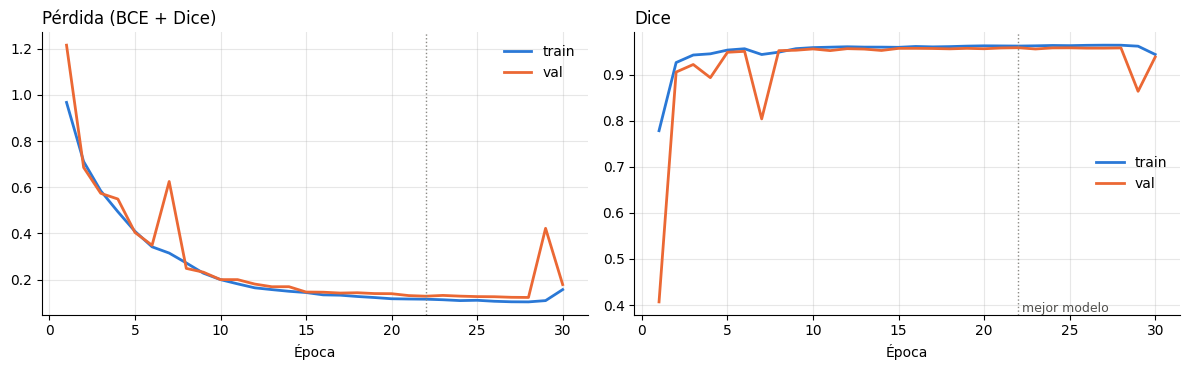

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, metric, title in [(axes[0], "loss", "Pérdida (BCE + Dice)"), (axes[1], "dice", "Dice")]:
    ax.plot(history["epoch"], history[f"train_{metric}"], color=C_TRUE, lw=2, label="train")
    ax.plot(history["epoch"], history[f"val_{metric}"], color=C_PRED, lw=2, label="val")
    ax.axvline(best_epoch, color="#8a8984", ls=":", lw=1)
    ax.set_title(title, loc="left"); ax.set_xlabel("Época"); ax.grid(alpha=0.3)
    ax.legend(frameon=False)
axes[1].text(best_epoch, axes[1].get_ylim()[0], " mejor modelo", color="#52514e", fontsize=9, va="bottom")
fig.tight_layout()
plt.show()

En las primeras épocas el Dice de validación suele ser mucho más bajo e inestable que el de entrenamiento. En evaluación, BatchNorm usa estadísticas acumuladas durante el entrenamiento que todavía no se han estabilizado. Por eso se juzga la **tendencia** de las curvas y no una época aislada.

## 7. Evaluación en el conjunto de prueba

El conjunto de prueba **no participó en ninguna decisión**: ni en el entrenamiento ni en la elección del mejor modelo. Por eso su Dice es una estimación honesta del desempeño en imágenes nuevas **del mismo tipo** (Montgomery y Shenzhen).

Dice en test: media 0.964 | mediana 0.970 | mínimo 0.795


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
montgomery,21.0,0.978,0.009,0.952,0.974,0.982,0.984,0.989
shenzhen,85.0,0.961,0.027,0.795,0.959,0.970,0.977,0.984


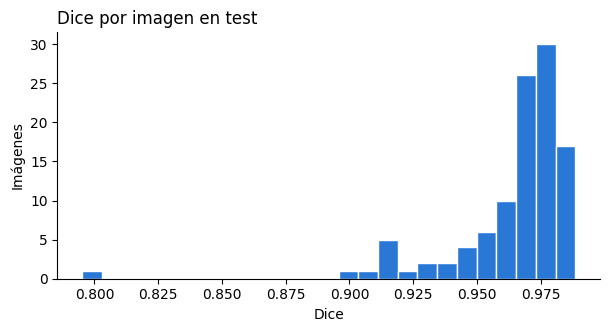

In [12]:
@torch.no_grad()
def predict_logits(model, loader):
    model.eval()
    return torch.cat([model(images.to(DEVICE)).cpu() for images, _ in loader])

test_logits = predict_logits(model, loaders["test"])
test_masks = torch.stack([datasets["test"][i][1] for i in range(len(datasets["test"]))])
test_dice = dice_score(test_logits, test_masks).numpy()

test_ids = datasets["test"].image_ids
results = pd.DataFrame({"image_id": test_ids, "dice": test_dice}).merge(split[["image_id", "source"]])
print(f"Dice en test: media {test_dice.mean():.3f} | mediana {np.median(test_dice):.3f} | mínimo {test_dice.min():.3f}")
display(results.groupby("source")["dice"].describe().round(3))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(test_dice, bins=25, color=C_TRUE, edgecolor="white")
ax.set_title("Dice por imagen en test", loc="left"); ax.set_xlabel("Dice"); ax.set_ylabel("Imágenes")
plt.show()

El promedio esconde los casos difíciles. Hay que **mirar los peores**: ahí se ve qué tipo de error comete la red (bordes, zonas opacas por enfermedad, ápices, ángulos costofrénicos).

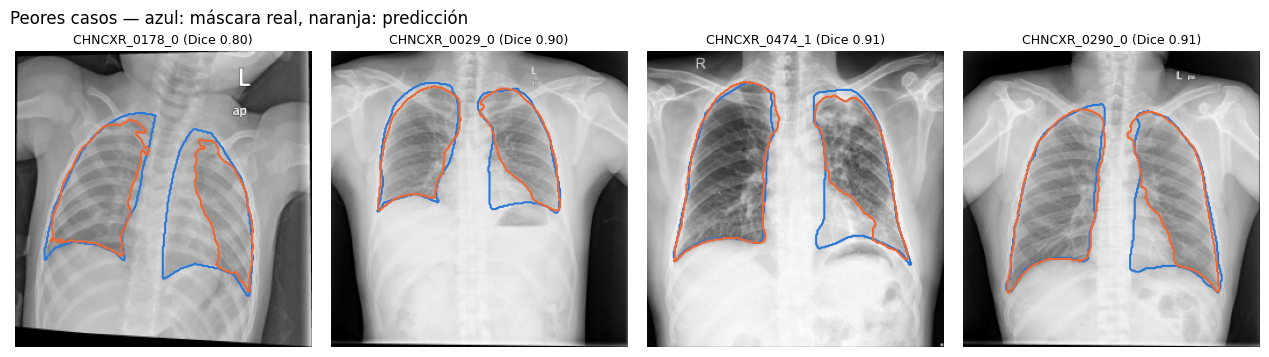

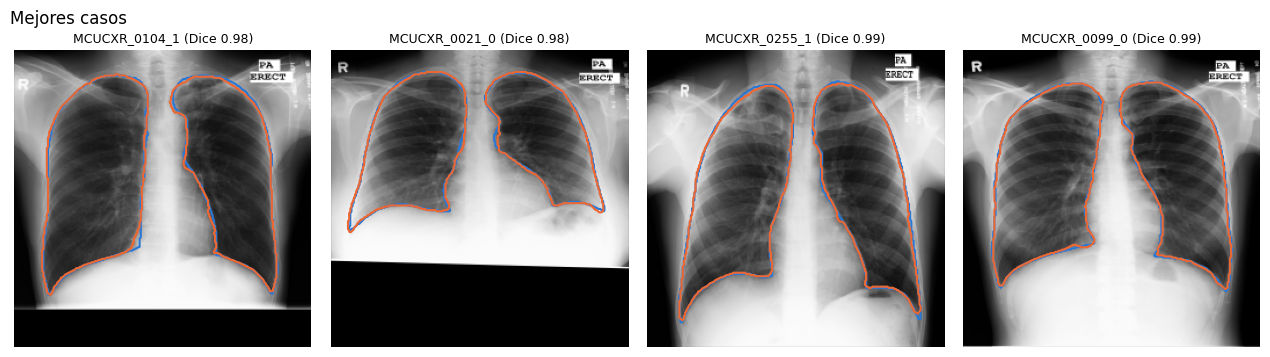

In [13]:
def show_predictions(image_ids, images, true_masks, logits, title):
    fig, axes = plt.subplots(1, len(image_ids), figsize=(3.2 * len(image_ids), 3.6))
    for ax, image_id, img, true, logit in zip(np.atleast_1d(axes), image_ids, images, true_masks, logits):
        pred = (torch.sigmoid(logit) > 0.5).float()
        ax.imshow(img.squeeze(), cmap="gray")
        if true is not None:
            ax.contour(true.squeeze(), levels=[0.5], colors=C_TRUE, linewidths=1.5)
        ax.contour(pred.squeeze(), levels=[0.5], colors=C_PRED, linewidths=1.5)
        ax.set_title(image_id, fontsize=9); ax.axis("off")
    fig.suptitle(title, x=0.01, ha="left")
    fig.tight_layout()
    plt.show()

test_images = torch.stack([datasets["test"][i][0] for i in range(len(datasets["test"]))])
order = np.argsort(test_dice)
worst, best = order[:4], order[-4:]
show_predictions([f"{test_ids[i]} (Dice {test_dice[i]:.2f})" for i in worst], test_images[worst], test_masks[worst],
                 test_logits[worst], "Peores casos — azul: máscara real, naranja: predicción")
show_predictions([f"{test_ids[i]} (Dice {test_dice[i]:.2f})" for i in best], test_images[best], test_masks[best],
                 test_logits[best], "Mejores casos")

### 7.1 ¿Qué "ve" la red?

La salida antes del umbral es un **mapa de probabilidad**. Los valores intermedios (ni 0 ni 1) indican dónde la red duda, normalmente en los bordes.

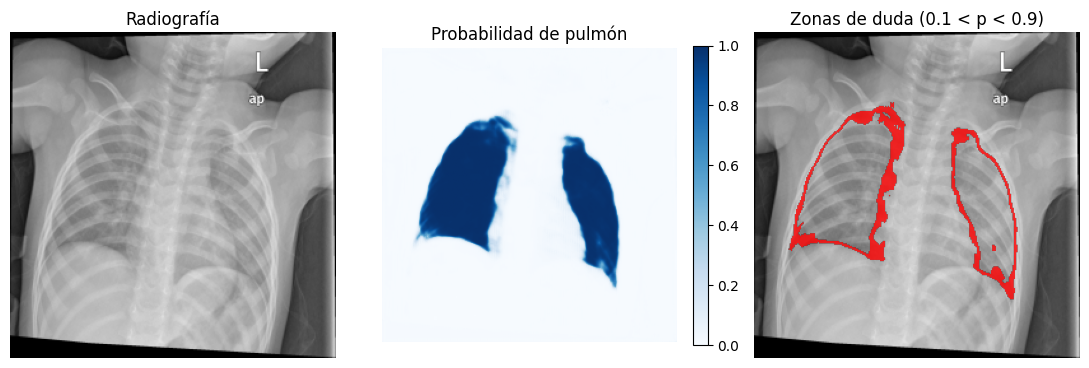

In [14]:
i = worst[0]
probs = torch.sigmoid(test_logits[i]).squeeze()
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
axes[0].imshow(test_images[i].squeeze(), cmap="gray"); axes[0].set_title("Radiografía")
im = axes[1].imshow(probs, cmap="Blues", vmin=0, vmax=1); axes[1].set_title("Probabilidad de pulmón")
fig.colorbar(im, ax=axes[1], fraction=0.046)
uncertain = ((probs > 0.1) & (probs < 0.9)).float()
axes[2].imshow(test_images[i].squeeze(), cmap="gray"); axes[2].imshow(np.ma.masked_where(uncertain == 0, uncertain), cmap="autumn", alpha=0.8)
axes[2].set_title("Zonas de duda (0.1 < p < 0.9)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

## 8. Aplicación a TBX11K

Este es el uso real en el proyecto: segmentar radiografías **que no tienen máscara**. No se puede calcular el Dice porque no hay respuesta correcta, así que la revisión es **visual**.

El reto es el **cambio de dominio**: la red aprendió con radiografías de dos hospitales (EE. UU. y China) y ahora ve imágenes de otros hospitales, equipos y pacientes. Diferencias de contraste, encuadre, artefactos o patologías que no vio al entrenar pueden producir errores.

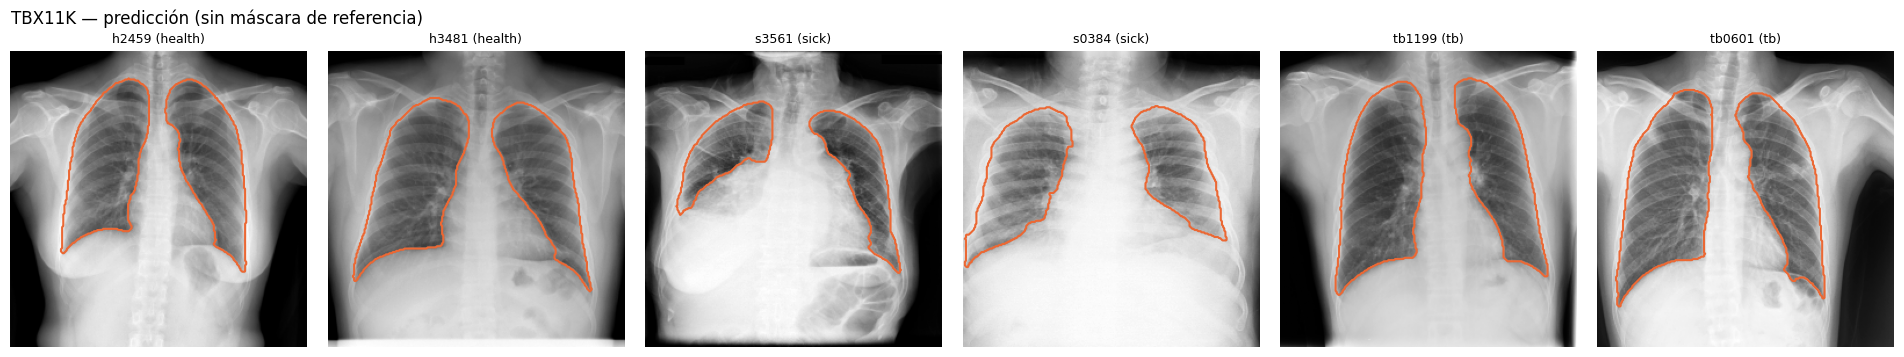

In [15]:
sample = load_subset().groupby("source_class").sample(2, random_state=SEED)
tbx_images = torch.stack([
    torch.from_numpy(cv2.resize(load_gray(p), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA) / 255.0).float()[None]
    for p in sample["rel_path"]
])
model.eval()
with torch.no_grad():
    tbx_logits = model(tbx_images.to(DEVICE)).cpu()
show_predictions([f"{r.image_id} ({r.source_class})" for r in sample.itertuples()], tbx_images, [None] * len(sample),
                 tbx_logits, "TBX11K — predicción (sin máscara de referencia)")

Aquí hay que buscar: pulmones recortados (sobre todo los **ápices**, donde se concentran las lesiones de TB), fragmentos sueltos fuera del tórax, pulmones unidos por el mediastino o zonas opacas por enfermedad que la red excluye. Estos errores son los que el proyecto revisará en el notebook de control de calidad y los que el posprocesamiento (quedarse con los dos componentes más grandes y rellenar huecos) corrige en parte.

## 9. Qué hay que tener en cuenta

**Datos**
- **Calidad de las máscaras**: la red aprende lo que dicen las máscaras, incluidos sus errores o criterios. Por ejemplo, si los anotadores excluyeron el corazón o no, la red hará lo mismo.
- **Fuga de información**: una misma imagen o paciente no puede estar en train y en test. En Montgomery y Shenzhen cada imagen es un paciente distinto; en otros datasets hay que dividir **por paciente**.
- **Mismo preprocesamiento al entrenar y al predecir**: mismo tamaño, escala de grises y normalización a [0, 1]. Una diferencia aquí degrada la predicción silenciosamente.

**Entrenamiento**
- **Sobreajuste**: vigilar las curvas de validación y guardar el mejor modelo según validación (no el último).
- **El conjunto de prueba se usa una sola vez.** Si se ajustan hiperparámetros mirando el test, deja de ser una estimación honesta.
- **Tasa de aprendizaje**: si es muy alta, la pérdida oscila o diverge; si es muy baja, el aprendizaje es lento. `1e-3` con Adam es un buen punto de partida.
- **Lote y memoria**: resolución, tamaño de lote y número de canales determinan la memoria de GPU. Con lotes muy pequeños (< 4), BatchNorm se vuelve inestable.
- **Reproducibilidad**: fijar semillas. Aun así, algunas operaciones de GPU no son deterministas y los resultados pueden variar levemente entre ejecuciones; para comparar métodos conviene repetir con varias semillas o reportar la variación.

**Predicción**
- `model.eval()` y `torch.no_grad()` siempre.
- **El umbral 0.5 es una convención**; se puede ajustar en validación si la red es sistemáticamente conservadora o generosa.
- **Resolución**: predecir a 256 y reescalar a 512 produce bordes menos precisos que predecir a 512. El proyecto trabaja a 512 para no perder detalle en los bordes, que es donde las características radiómicas son más sensibles.
- **Cambio de dominio**: un Dice alto en test no garantiza buen desempeño en TBX11K. Por eso existe la revisión visual.

## 10. Attention U-Net: la variante que viene después

Attention U-Net (Oktay et al., 2018) conserva toda la estructura de U-Net y cambia **solo las conexiones de salto**.

En U-Net, el salto copia **todo** el mapa del codificador, incluidas regiones irrelevantes (fondo, hombros, abdomen). Attention U-Net agrega una **compuerta de atención** en cada salto:

1. Toma el mapa del codificador (detalle espacial) y la señal del decodificador del nivel inferior (contexto: "qué se está buscando").
2. Calcula un **coeficiente entre 0 y 1 para cada píxel**: qué tan relevante es esa posición.
3. Multiplica el mapa del codificador por esos coeficientes antes de concatenarlo.

Resultado: la red aprende a **atenuar las regiones irrelevantes y destacar las relevantes**, sin supervisión adicional. Tiene más parámetros y es algo más lenta. En el proyecto se entrena con **la misma rutina, los mismos datos y los mismos hiperparámetros** que U-Net, para que la diferencia observada se deba solo a la arquitectura.

## 11. Relación con el proyecto

En el proyecto no se usa esta implementación manual sino la de **MONAI**, una librería especializada en imagen médica que ya trae `UNet` y `AttentionUnet` probadas:

```python
from monai.networks.nets import UNet, AttentionUnet

unet = UNet(spatial_dims=2, in_channels=1, out_channels=1,
            channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2))
attention_unet = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1,
                               channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2))
```

La idea es la misma de este tutorial. Hay diferencias menores de implementación: por ejemplo, la `UNet` de MONAI reduce la resolución con convoluciones de paso 2 en lugar de *max pooling*.

La rutina de entrenamiento del proyecto (`src/tbseg/segmentation/train.py`) seguirá los mismos pasos:

| Tutorial | Proyecto |
|---|---|
| 256×256, 30 épocas | 512×512, más épocas y detención temprana |
| U-Net manual | `UNet` y `AttentionUnet` de MONAI, misma rutina |
| Mejor modelo en memoria | Pesos guardados en `models/` |
| Revisión visual de 6 imágenes | Predicción de las 1600 imágenes del subconjunto + control de calidad |

## Referencias

- Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. *MICCAI*.
- Oktay, O., et al. (2018). Attention U-Net: Learning Where to Look for the Pancreas. *MIDL*.
- Milletari, F., Navab, N., & Ahmadi, S. (2016). V-Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation. *3DV* (pérdida Dice).
- Jaeger, S., et al. (2014). Two public chest X-ray datasets for computer-aided screening of pulmonary diseases. *Quant. Imaging Med. Surg.*
- Stirenko, S., et al. (2018). Chest X-Ray Analysis of Tuberculosis by Deep Learning with Segmentation and Augmentation. *IEEE ELNANO* (máscaras de Shenzhen).